# Chicken and Duck Image Classification

In [1]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 1. Environment Setup and Data Acquisition

In [23]:
from google.colab import files

# Upload kaggle.json
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [3]:
!kaggle datasets download -d roudranildas/chicken-images-classification-dataset
!unzip chicken-images-classification-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/roudranildas/chicken-images-classification-dataset
License(s): unknown
100% 43.0M/43.0M [00:00<00:00, 176MB/s]

Archive:  chicken-images-classification-dataset.zip
  inflating: data/chicken-images/data/test/0U5DJ4AHL7U8.jpg  
  inflating: data/chicken-images/data/test/0YRRH5UO983S.jpg  
  inflating: data/chicken-images/data/test/17ZH2WHTIPL8.jpg  
  inflating: data/chicken-images/data/test/1O9LZD4GDLEG.jpg  
  inflating: data/chicken-images/data/test/1OX6JD87ZL6M.jpg  
  inflating: data/chicken-images/data/test/1WHCYYP4QBBB.jpg  
  inflating: data/chicken-images/data/test/1ZLB7IELNMCD.jpg  
  inflating: data/chicken-images/data/test/21AEDSI4YQ9L.jpg  
  inflating: data/chicken-images/data/test/2GGVG9VUE5VP.jpg  
  inflating: data/chicken-images/data/test/2IH2F7SXSTFS.jpg  
  inflating: data/chicken-images/data/test/2MD30734HGEK.jpg  
  inflating: data/chicken-images/data/test/30XSIDP797YK.jpg  
  inflating: data/chicken-images/data/test/37RO

In [4]:
import os
import shutil

base_dir = "/content/organized-data"
splits = ['train', 'val', 'test']
classes = ['chicken', 'duck']

# Create folders
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Copy data
for cls in classes:
    src_root = f"/content/data/{cls}-images/data"
    for split in splits:
        src = os.path.join(src_root, split)
        dst = os.path.join(base_dir, split, cls)
        for file in os.listdir(src):
            shutil.copy(os.path.join(src, file), dst)

## 2. Data Preprocessing and Loading

In [5]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

base_dir = "/content/organized-data"

train_ds = datasets.ImageFolder(os.path.join(base_dir, "train"), transform=train_transform)
val_ds = datasets.ImageFolder(os.path.join(base_dir, "val"), transform=test_transform)
test_ds = datasets.ImageFolder(os.path.join(base_dir, "test"), transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print("Classes:", train_ds.classes)

Classes: ['chicken', 'duck']


## 3. Exploratory Data Analysis (EDA)

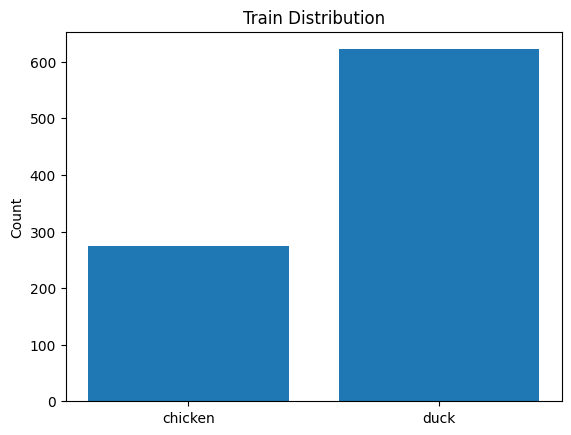

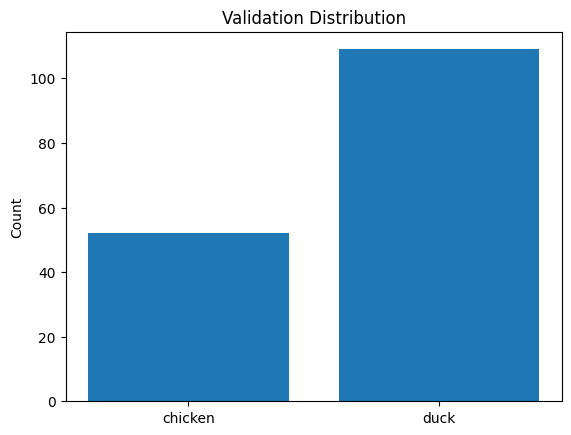

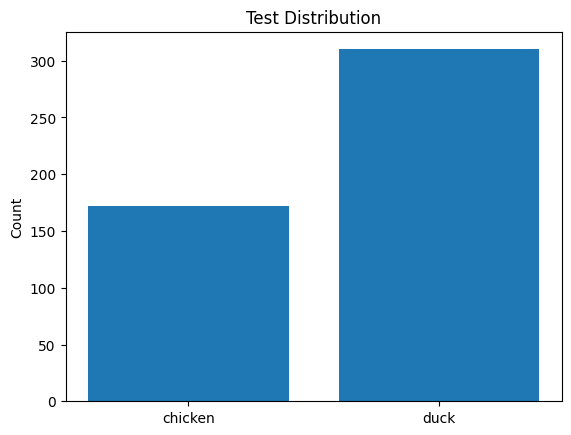

In [7]:
from collections import Counter

train_labels = [label for _, label in train_ds]
val_labels   = [label for _, label in val_ds]
test_labels  = [label for _, label in test_ds]

def plot_distribution(labels, title):
    counts = Counter(labels)
    names = train_ds.classes
    values = [counts[i] for i in range(len(names))]

    plt.bar(names, values)
    plt.title(title)
    plt.ylabel("Count")
    plt.show()

plot_distribution(train_labels, "Train Distribution")
plot_distribution(val_labels, "Validation Distribution")
plot_distribution(test_labels, "Test Distribution")

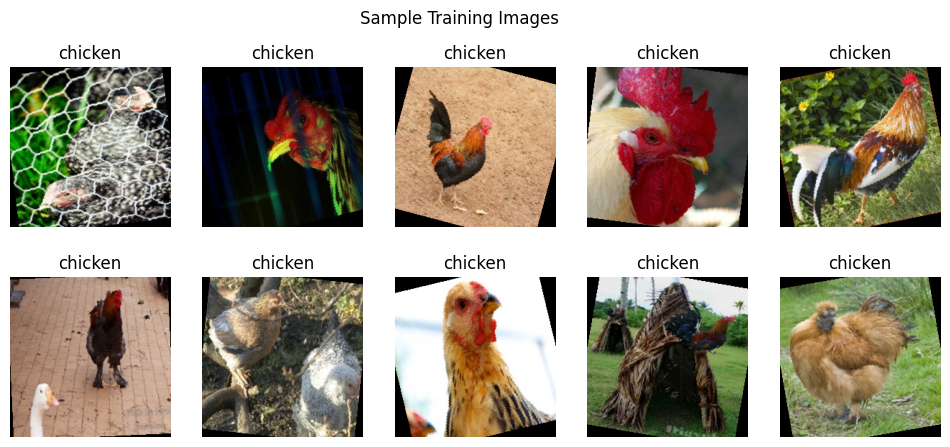

In [8]:
import matplotlib.pyplot as plt

def show_samples(dataset, title):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title)

    for i in range(10):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # CHW → HWC

        axes[i//5, i%5].imshow(img)
        axes[i//5, i%5].set_title(train_ds.classes[label])
        axes[i//5, i%5].axis('off')

    plt.show()

show_samples(train_ds, "Sample Training Images")

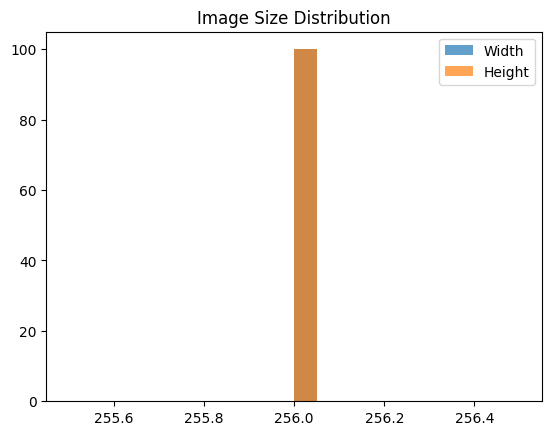

In [9]:
from PIL import Image

widths, heights = [], []

for path, _ in train_ds.samples[:100]:
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

plt.hist(widths, bins=20, alpha=0.7, label="Width")
plt.hist(heights, bins=20, alpha=0.7, label="Height")
plt.legend()
plt.title("Image Size Distribution")
plt.show()

/tmp/ipykernel_4183/512161028.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([r, g, b], labels=['R', 'G', 'B'])


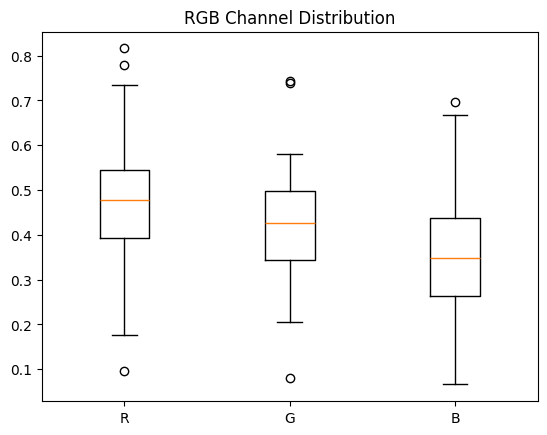

In [10]:
def rgb_stats(dataset, n=50):
    r, g, b = [], [], []

    for i in range(n):
        img, _ = dataset[i]
        img = img.numpy()

        r.append(img[0].mean())
        g.append(img[1].mean())
        b.append(img[2].mean())

    return r, g, b

r, g, b = rgb_stats(train_ds)

plt.boxplot([r, g, b], labels=['R', 'G', 'B'])
plt.title("RGB Channel Distribution")
plt.show()

## 4. Model Definition (Transfer Learning with ResNet18)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Modify final layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


## 5. Training Setup

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [13]:
def evaluate(model, loader):
    model.eval()
    loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return loss_total / len(loader), 100 * correct / total

## 6. Model Training

In [14]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    _, train_acc = evaluate(model, train_loader)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%\n")

Epoch 1/50
Train Loss: 0.7040 | Val Loss: 0.6610 | Val Acc: 65.84%

Epoch 2/50
Train Loss: 0.5684 | Val Loss: 0.5751 | Val Acc: 73.29%

Epoch 3/50
Train Loss: 0.5012 | Val Loss: 0.5054 | Val Acc: 77.02%

Epoch 4/50
Train Loss: 0.4506 | Val Loss: 0.4567 | Val Acc: 83.85%

Epoch 5/50
Train Loss: 0.4297 | Val Loss: 0.4139 | Val Acc: 85.71%

Epoch 6/50
Train Loss: 0.3698 | Val Loss: 0.3868 | Val Acc: 86.34%

Epoch 7/50
Train Loss: 0.3381 | Val Loss: 0.3523 | Val Acc: 86.34%

Epoch 8/50
Train Loss: 0.3186 | Val Loss: 0.3329 | Val Acc: 88.20%

Epoch 9/50
Train Loss: 0.2941 | Val Loss: 0.3209 | Val Acc: 86.96%

Epoch 10/50
Train Loss: 0.2873 | Val Loss: 0.3069 | Val Acc: 88.20%

Epoch 11/50
Train Loss: 0.2750 | Val Loss: 0.2926 | Val Acc: 89.44%

Epoch 12/50
Train Loss: 0.2889 | Val Loss: 0.3027 | Val Acc: 88.82%

Epoch 13/50
Train Loss: 0.2486 | Val Loss: 0.2921 | Val Acc: 88.82%

Epoch 14/50
Train Loss: 0.2411 | Val Loss: 0.2958 | Val Acc: 88.20%

Epoch 15/50
Train Loss: 0.2620 | Val Loss: 

## 7. Training Evaluation and Visualization

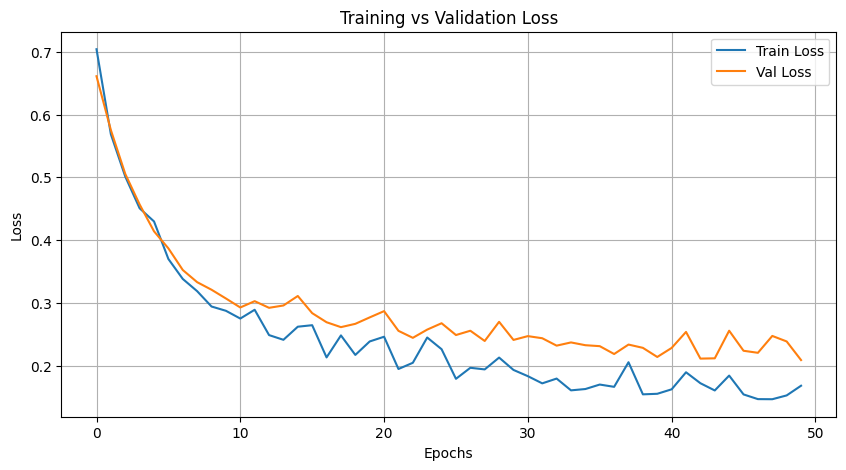

In [15]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

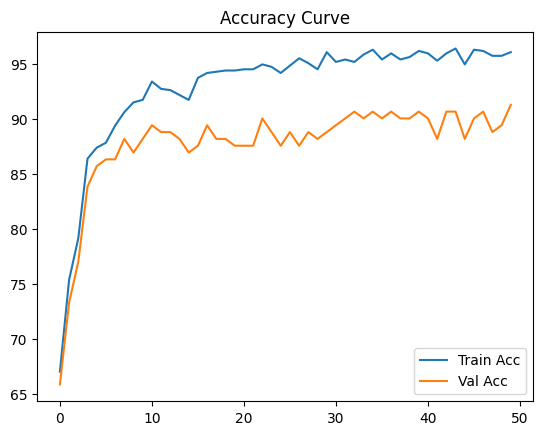

In [16]:
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

## 8. Test Set Evaluation and Misclassified Samples

In [17]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

              precision    recall  f1-score   support

     chicken       0.97      0.88      0.92       172
        duck       0.94      0.98      0.96       310

    accuracy                           0.95       482
   macro avg       0.95      0.93      0.94       482
weighted avg       0.95      0.95      0.95       482



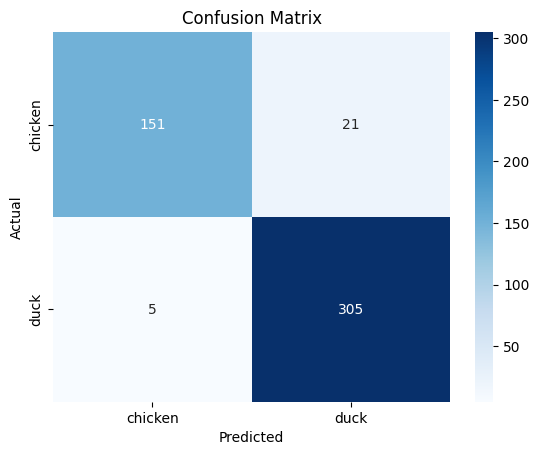

In [18]:
cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
wrong = []

for i in range(len(all_preds)):
    if all_preds[i] != all_labels[i]:
        wrong.append(i)

print("Total misclassified:", len(wrong))

Total misclassified: 26


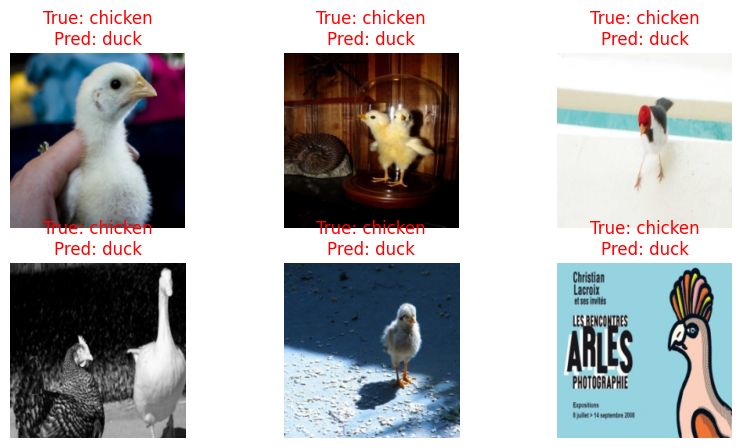

In [20]:
fig = plt.figure(figsize=(10,5))

for i, idx in enumerate(wrong[:6]):
    img, label = test_ds[idx]
    img = img.permute(1,2,0)

    ax = fig.add_subplot(2,3,i+1)
    ax.imshow(img)
    ax.set_title(f"True: {train_ds.classes[label]}\nPred: {train_ds.classes[all_preds[idx]]}",
                 color='red')
    ax.axis('off')

plt.show()

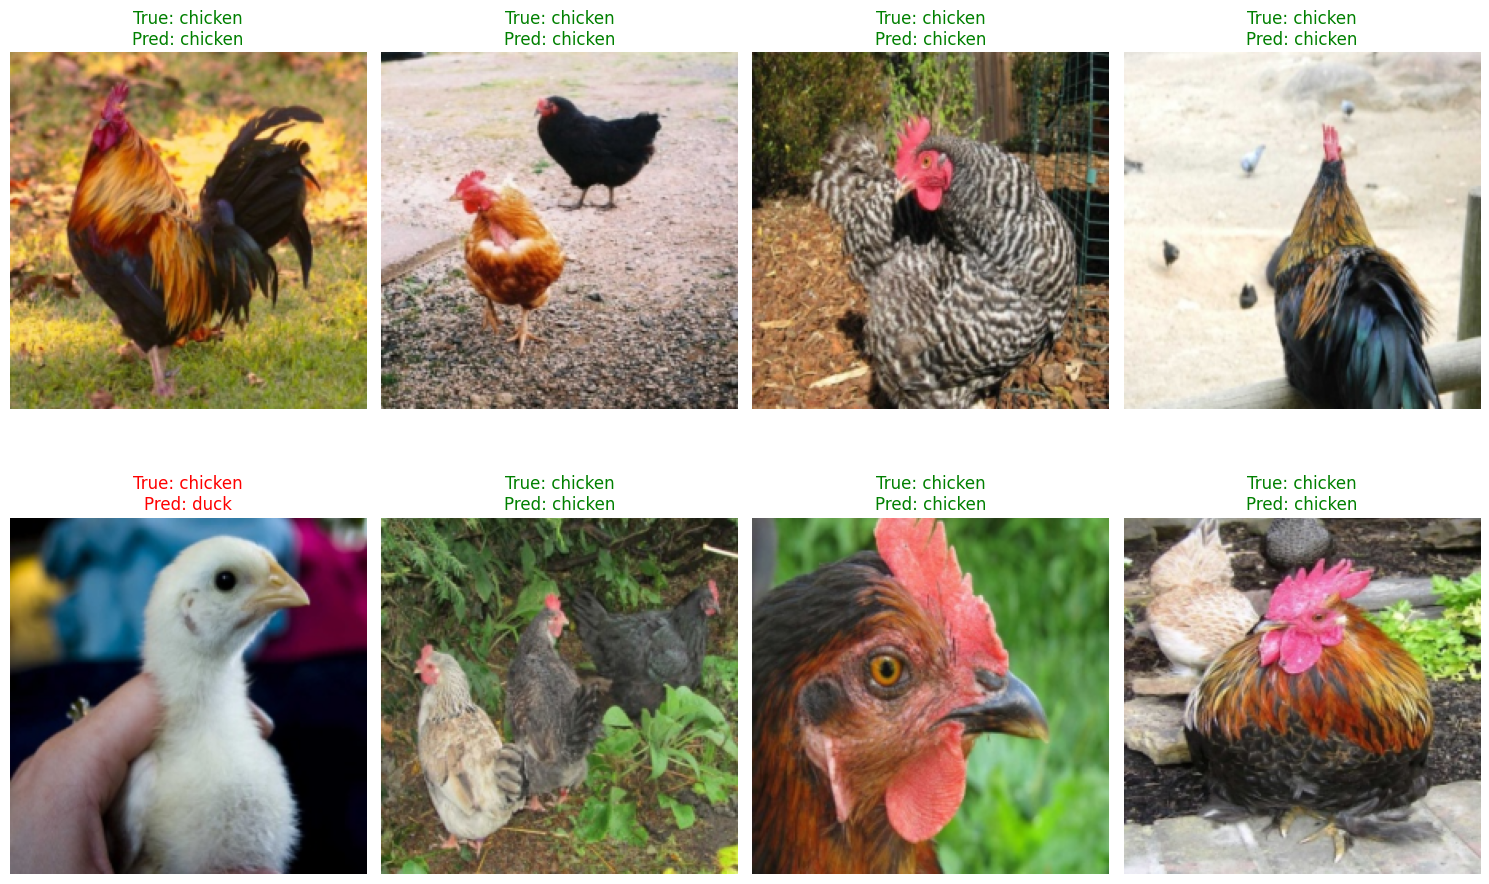

In [21]:
import matplotlib.pyplot as plt

# Function to unnormalize (if needed)
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    plt.imshow(img)
    plt.axis('off')

model.eval()

# Get one batch from test set
images, labels = next(iter(test_loader))
images = images.to(device)

# Predictions
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

# Plot images
fig = plt.figure(figsize=(15, 10))

for i in range(min(8, len(images))):   # show 8 images
    ax = fig.add_subplot(2, 4, i+1)

    imshow(images[i])

    true_label = train_ds.classes[labels[i]]
    pred_label = train_ds.classes[preds[i]]

    ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                 color=("green" if true_label == pred_label else "red"))

plt.tight_layout()
plt.show()

## Analysis Summary and Results

This notebook demonstrates a chicken and duck image classification task using transfer learning with a pre-trained ResNet18 model.

### Key Steps:
1.  **Environment Setup**: Configured PyTorch to use GPU if available.
2.  **Data Acquisition**: Downloaded and unzipped the 'chicken-images-classification-dataset' from Kaggle.
3.  **Data Organization**: Structured the dataset into `train`, `val`, and `test` directories for 'chicken' and 'duck' classes.
4.  **Data Preprocessing**:
    *   Applied image transformations including resizing, random horizontal flip, and random rotation for training data augmentation.
    *   Resized test and validation images.
    *   Loaded data using `ImageFolder` and `DataLoader`.
5.  **Exploratory Data Analysis (EDA)**:
    *   Visualized the distribution of classes in train, validation, and test sets.
    *   Displayed sample training images.
    *   Analyzed image size distribution and RGB channel statistics.
6.  **Model Definition**:
    *   Loaded a pre-trained ResNet18 model.
    *   Modified the final fully connected layer to output 2 classes (chicken, duck).
    *   Froze all layers except the final classification layer to leverage transfer learning effectively.
7.  **Training**:
    *   Used Cross-Entropy Loss and Adam optimizer.
    *   Trained the model for 50 epochs.
    *   Monitored and plotted training and validation loss, and accuracy curves, showing good convergence.

### Results:
*   **Final Validation Accuracy**: Achieved a validation accuracy of **91.30%** after 50 epochs.
*   **Test Set Performance**: The model performed well on the unseen test set, demonstrating:
    *   Overall **accuracy of 95%**.
    *   High precision, recall, and F1-scores for both 'chicken' and 'duck' classes (e.g., chicken: 0.97 precision, 0.88 recall; duck: 0.94 precision, 0.98 recall).
*   **Confusion Matrix**: Visualized the confusion matrix, which confirmed a low number of misclassifications.
*   **Misclassified Samples**: Identified and visualized some of the misclassified images from the test set, providing insight into where the model struggles.